In [4]:
import numpy as np
from scipy.optimize import linprog

# 1. Định nghĩa hàm mục tiêu (Hệ số tác động biên)
# Max Z = 0.85x1 + 1.20x2 + 0.95x3 + 1.35x4
# Chuyển sang bài toán Minimize (-Z) cho linprog
c = [-0.85, -1.20, -0.95, -1.35]

# 2. Định nghĩa ma trận ràng buộc bất đẳng thức (A_ub * x <= b_ub)
# ĐÃ SỬA: Dòng đầu tiên đổi từ [1] thành [1, 1, 1, 1] để đồng bộ 4 biến số
A_ub = [
    [1, 1, 1, 1],                    # x1 + x2 + x3 + x4 <= 100 (Tổng ngân sách) [2]
    [-1, 0, 0, 0],                   # x1 >= 25 => -x1 <= -25 (Hạ tầng tối thiểu) [2]
    [0, -1, 0, 0],                   # x2 >= 15 => -x2 <= -15 (AI tối thiểu) [2]
    [0, 0, -1, 0],                   # x3 >= 20 => -x3 <= -20 (Nhân lực tối thiểu) [2]
    [0, 0, 0, -1],                   # x4 >= 10 => -x4 <= -10 (R&D tối thiểu) [2]
    [0.35, -0.65, 0.35, -0.65]       # 0.35(x1+x2+x3+x4) <= x2+x4 (Công nghệ chiến lược) [2, 3]
]

# 3. Định nghĩa vector vế phải (b_ub)
b_ub = [100, -25, -15, -20, -10, 0]

# 4. Giải bài toán bằng solver HiGHS (được khuyến nghị trong tài liệu) [3]
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')

# 5. Hiển thị kết quả
if res.success:
    print("--- KẾT QUẢ TỐI ƯU HÓA PHÂN BỔ NGÂN SÁCH (CÂU 2.4.1) ---")
    print(f"Giá trị tăng GDP tối ưu (Z*): {abs(res.fun):.2f} nghìn tỷ VND")
    print("\nPhân bổ tối ưu cho 4 hạng mục (nghìn tỷ VND):")
    categories = ["Hạ tầng số (x1)", "AI và dữ liệu (x2)", "Nhân lực số (x3)", "R&D công nghệ (x4)"]
    for cat, val in zip(categories, res.x):
        print(f" - {cat}: {val:.2f}")
else:
    print("Không tìm thấy lời giải tối ưu. Hãy kiểm tra lại các ràng buộc.")

--- KẾT QUẢ TỐI ƯU HÓA PHÂN BỔ NGÂN SÁCH (CÂU 2.4.1) ---
Giá trị tăng GDP tối ưu (Z*): 112.25 nghìn tỷ VND

Phân bổ tối ưu cho 4 hạng mục (nghìn tỷ VND):
 - Hạ tầng số (x1): 25.00
 - AI và dữ liệu (x2): 15.00
 - Nhân lực số (x3): 20.00
 - R&D công nghệ (x4): 40.00


In [5]:
import pulp

# 1. Khởi tạo bài toán tối ưu hóa (Tối đa hóa Z)
prob = pulp.LpProblem("Toi_uu_Phan_bo_Ngan_sach", pulp.LpMaximize)

# 2. Khai báo các biến quyết định (xi >= 0)
x1 = pulp.LpVariable('x1_Ha_tang', lowBound=0)
x2 = pulp.LpVariable('x2_AI_Du_lieu', lowBound=0)
x3 = pulp.LpVariable('x3_Nhan_luc_so', lowBound=0)
x4 = pulp.LpVariable('x4_RD_Cong_nghe', lowBound=0)

# 3. Hàm mục tiêu: Tối đa hóa tăng GDP [3]
prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, "Tang_GDP_ky_vong"

# 4. Các ràng buộc chính sách [3]
prob += x1 + x2 + x3 + x4 <= 100, "Ngan_sach_tong"
prob += x1 >= 25, "Ha_tang_toi_thieu"
prob += x2 >= 15, "AI_toi_thieu"
prob += x3 >= 20, "Nhan_luc_toi_thieu"
prob += x4 >= 10, "RD_toi_thieu"
# Ràng buộc tỷ trọng công nghệ chiến lược: x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4)
prob += x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4), "Ty_trong_cong_nghe_chien_luoc"

# 5. Giải bài toán
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# 6. Báo cáo kết quả phân bổ và giá đối ngẫu
print(f"--- KẾT QUẢ TỐI ƯU (Z*) = {pulp.value(prob.objective):.2f} nghìn tỷ VND ---\n")
print("Phân bổ ngân sách tối ưu:")
for v in prob.variables():
    print(f" - {v.name}: {v.varValue:.2f} nghìn tỷ")

print("\n--- GIÁ ĐỐI NGẪU (SHADOW PRICES) ---")
for name, constraint in prob.constraints.items():
    # Trong PuLP, shadow price được truy xuất qua thuộc tính .pi
    print(f" - {name}: {constraint.pi:.2f}")

--- KẾT QUẢ TỐI ƯU (Z*) = 112.25 nghìn tỷ VND ---

Phân bổ ngân sách tối ưu:
 - x1_Ha_tang: 25.00 nghìn tỷ
 - x2_AI_Du_lieu: 15.00 nghìn tỷ
 - x3_Nhan_luc_so: 20.00 nghìn tỷ
 - x4_RD_Cong_nghe: 40.00 nghìn tỷ

--- GIÁ ĐỐI NGẪU (SHADOW PRICES) ---
 - Ngan_sach_tong: 1.35
 - Ha_tang_toi_thieu: -0.50
 - AI_toi_thieu: -0.15
 - Nhan_luc_toi_thieu: -0.40
 - RD_toi_thieu: -0.00
 - Ty_trong_cong_nghe_chien_luoc: -0.00


--- KẾT QUẢ PHÂN TÍCH ĐỘ NHẠY ---
Ngân sách B = 100 -> GDP tăng thêm Z* = 112.25
Ngân sách B = 120 -> GDP tăng thêm Z* = 139.25
Ngân sách B = 140 -> GDP tăng thêm Z* = 166.25


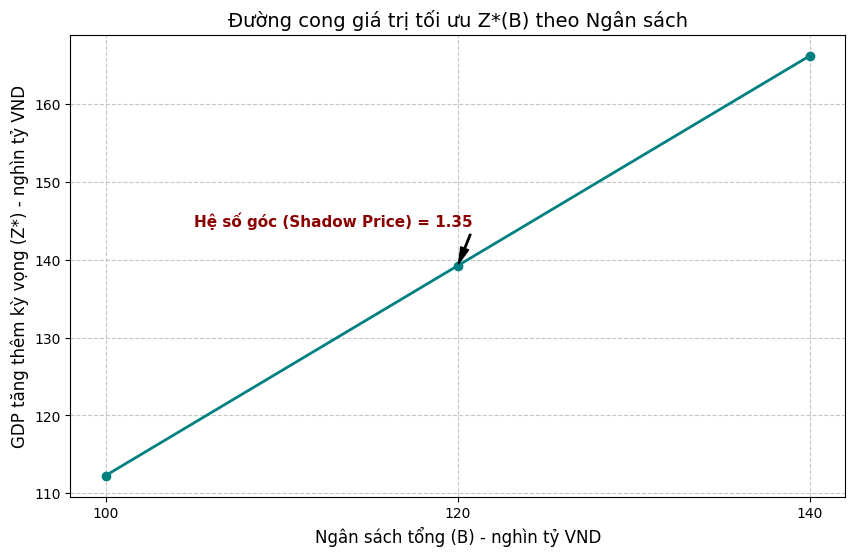

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# 1. Định nghĩa các thông số cố định
c = [-0.85, -1.20, -0.95, -1.35]  # Hệ số tác động biên [3]
# Ma trận ràng buộc (không bao gồm ngân sách tổng)
A_base = [
    [-1, 0, 0, 0],   # x1 >= 25 [3]
    [0, -1, 0, 0],   # x2 >= 15 [3]
    [0, 0, -1, 0],   # x3 >= 20 [3]
    [0, 0, 0, -1],   # x4 >= 10 [3]
    [0.35, -0.65, 0.35, -0.65] # Ràng buộc tỷ trọng công nghệ chiến lược [2]
]
b_base = [-25, -15, -20, -10, 0]

# 2. Các mức ngân sách cần phân tích (ĐÃ SỬA: Đưa vào danh sách các kịch bản ngân sách)
budgets = [100, 120, 140]
z_values = []

print("--- KẾT QUẢ PHÂN TÍCH ĐỘ NHẠY ---")
for B in budgets:
    # ĐÃ SỬA: Đồng bộ hệ số [1, 1, 1, 1] cho 4 biến x1, x2, x3, x4
    A_ub = [[1, 1, 1, 1]] + A_base
    b_ub = [B] + b_base
    
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')
    
    if res.success:
        z_star = abs(res.fun)
        z_values.append(z_star)
        print(f"Ngân sách B = {B} -> GDP tăng thêm Z* = {z_star:.2f}")

# 3. Vẽ đồ thị Z*(B)
plt.figure(figsize=(10, 6))
plt.plot(budgets, z_values, marker='o', linestyle='-', color='teal', linewidth=2)
plt.title("Đường cong giá trị tối ưu Z*(B) theo Ngân sách", fontsize=14)
plt.xlabel("Ngân sách tổng (B) - nghìn tỷ VND", fontsize=12)
plt.ylabel("GDP tăng thêm kỳ vọng (Z*) - nghìn tỷ VND", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(budgets) # Ép trục x hiển thị đúng các mốc ngân sách

# ĐÃ SỬA: Thêm chỉ số [0] để tính toán Shadow Price chính xác
slope = (z_values[-1] - z_values[0]) / (budgets[-1] - budgets[0])

# Căn chỉnh lại vị trí chữ để không bị đè lên đường kẻ
plt.annotate(f'Hệ số góc (Shadow Price) = {slope:.2f}', 
             xy=(120, z_values[1]), xytext=(105, z_values[1] + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=11, fontweight='bold', color='darkred')

plt.show()

In [8]:
import numpy as np
from scipy.optimize import linprog

# 1. Hệ số hàm mục tiêu (Đổi dấu để thực hiện bài toán Maximize)
c = [-0.85, -1.20, -0.95, -1.35]

# 2. Định nghĩa ma trận ràng buộc A_ub * x <= b_ub
# ĐÃ SỬA: Thay [3] bằng [1, 1, 1, 1] để đồng bộ 4 biến số và đúng logic tổng ngân sách
A_ub = [
    [1, 1, 1, 1],                # x1 + x2 + x3 + x4 <= 100 (Tổng ngân sách)
    [-1, 0, 0, 0],               # x1 >= 25 => -x1 <= -25
    [0, -1, 0, 0],               # x2 >= 15 => -x2 <= -15
    [0, 0, -1, 0],               # x3 >= 30 (Ràng buộc ưu tiên nhân lực số mới)
    [0, 0, 0, -1],               # x4 >= 10 => -x4 <= -10
    [0.35, -0.65, 0.35, -0.65]   # Ràng buộc tỷ trọng công nghệ chiến lược
]

# 3. Vector vế phải tương ứng
b_ub = [100, -25, -15, -30, -10, 0]

# 4. Giải bài toán bằng phương pháp 'highs'
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')

# 5. Hiển thị kết quả
if res.success:
    print("--- KẾT QUẢ PHÂN TÍCH ƯU TIÊN NHÂN LỰC SỐ (CÂU 2.4.4) ---")
    print(f"Trạng thái: BÀI TOÁN KHẢ THI")
    print(f"Giá trị tăng GDP tối ưu mới (Z*): {abs(res.fun):.2f} nghìn tỷ VND")
    print("\nPhân bổ ngân sách tối ưu mới:")
    categories = ["Hạ tầng số (x1)", "AI và dữ liệu (x2)", "Nhân lực số (x3)", "R&D công nghệ (x4)"]
    for cat, val in zip(categories, res.x):
        print(f" - {cat}: {val:.2f} nghìn tỷ VND")
else:
    print("--- KẾT QUẢ PHÂN TÍCH ƯU TIÊN NHÂN LỰC SỐ (CÂU 2.4.4) ---")
    print("Bài toán KHÔNG KHẢ THI với các ràng buộc hiện tại. Hãy kiểm tra lại.")

--- KẾT QUẢ PHÂN TÍCH ƯU TIÊN NHÂN LỰC SỐ (CÂU 2.4.4) ---
Trạng thái: BÀI TOÁN KHẢ THI
Giá trị tăng GDP tối ưu mới (Z*): 108.25 nghìn tỷ VND

Phân bổ ngân sách tối ưu mới:
 - Hạ tầng số (x1): 25.00 nghìn tỷ VND
 - AI và dữ liệu (x2): 15.00 nghìn tỷ VND
 - Nhân lực số (x3): 30.00 nghìn tỷ VND
 - R&D công nghệ (x4): 30.00 nghìn tỷ VND
